# Assignment: Text Classification for Spam Detection

Build a text classification model using Naive Bayes to classify SMS messages as **spam** or **ham** (non-spam), using TF-IDF for feature extraction.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('wordnet', quiet=True)

RANDOM_STATE = 42

## 1. Text Preprocessing

### 1.1 Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
urllib.request.urlretrieve(url, "sms.tsv")

sms_data = pd.read_csv('sms.tsv', sep='\t', header=None, names=['label', 'message'])
print(f"Dataset shape: {sms_data.shape}")
sms_data.head()

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64

Spam ratio: 13.4%


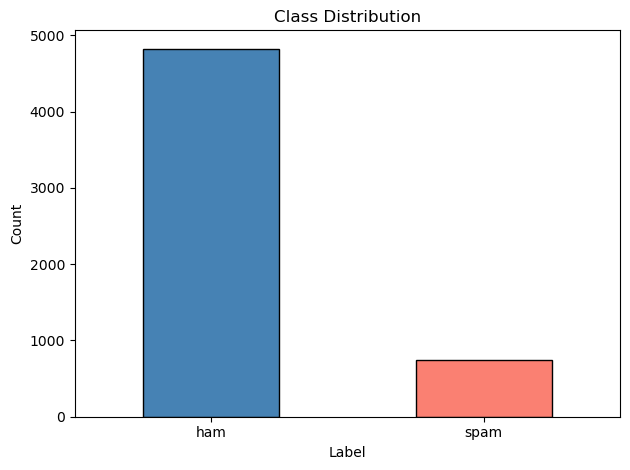

In [3]:
# Class distribution
print(sms_data['label'].value_counts())
print(f"\nSpam ratio: {sms_data['label'].value_counts(normalize=True)['spam']:.1%}")

sms_data['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.2 Tokenization, Stemming, and Stopword Removal

We chain three preprocessing steps into a single pipeline:
1. Lowercase + strip non-alphabetic characters
2. Tokenize with NLTK
3. Remove stopwords
4. Apply Porter stemming

In [7]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)      # keep only letters
    tokens = word_tokenize(text)               # tokenize
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]  # remove stopwords
    tokens = [stemmer.stem(t) for t in tokens] # stem
    return ' '.join(tokens)

sms_data['processed'] = sms_data['message'].apply(preprocess)

# Show a few examples
print("Original vs Preprocessed:\n")
for _, row in sms_data.sample(3, random_state=RANDOM_STATE).iterrows():
    print(f"[{row['label']}] Original : {row['message']}")
    print(f"          Processed: {row['processed']}")
    print()

Original vs Preprocessed:

[ham] Original : Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u get 3 u r cute:) 6 u r luvd:* 9 u r so lucky;) None? People hate u:
          Processed: squeeeeez christma hug lik frndshp den hug back get cute luvd lucki none peopl hate

[ham] Original : And also I've sorta blown him off a couple times recently so id rather not text him out of the blue looking for weed
          Processed: also ive sorta blown coupl time recent id rather text blue look weed

[ham] Original : Mmm thats better now i got a roast down me! id b better if i had a few drinks down me 2! Good indian?
          Processed: mmm that better got roast id better drink good indian



## 2. Feature Extraction

### 2.1 TF-IDF Vectorization

In [8]:
X = sms_data['processed']
y = sms_data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Fit TF-IDF on training data only to avoid data leakage
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Training set: {X_train_tfidf.shape}")
print(f"Test set:     {X_test_tfidf.shape}")

Training set: (4457, 5000)
Test set:     (1115, 5000)


### 2.2 Explore Most Important Features

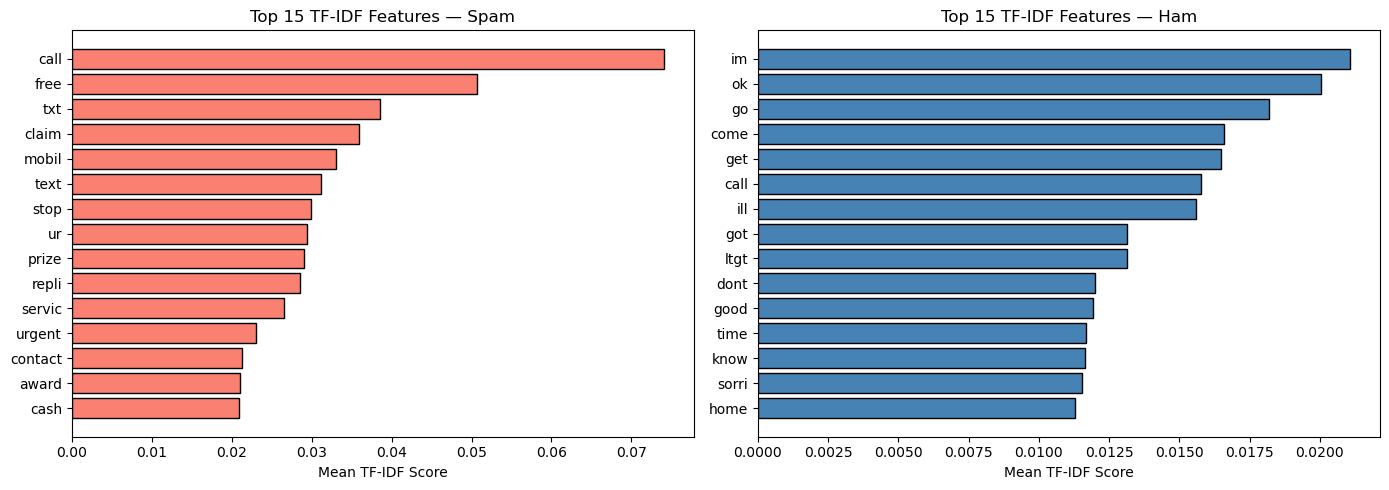

In [9]:
feature_names = vectorizer.get_feature_names_out()

def top_tfidf_features(label, top_n=15):
    mask = (y_train == label).values
    subset = X_train_tfidf[mask]
    mean_scores = subset.mean(axis=0).A1
    top_idx = mean_scores.argsort()[::-1][:top_n]
    return pd.DataFrame({'feature': feature_names[top_idx], 'mean_tfidf': mean_scores[top_idx]})

top_spam = top_tfidf_features('spam')
top_ham  = top_tfidf_features('ham')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, label, color in zip(axes, [top_spam, top_ham], ['Spam', 'Ham'], ['salmon', 'steelblue']):
    ax.barh(df['feature'][::-1], df['mean_tfidf'][::-1], color=color, edgecolor='black')
    ax.set_title(f'Top 15 TF-IDF Features — {label}')
    ax.set_xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.show()

## 3. Classification

### 3.1 Train Multinomial Naive Bayes

In [10]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print("Training complete.")

Training complete.


### 3.2 Evaluate the Model

In [11]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, pos_label='spam'):.4f}")
print()
print(classification_report(y_test, y_pred))

Accuracy : 0.9641
Precision: 1.0000
Recall   : 0.7315
F1-Score : 0.8450

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



### 3.3 Confusion Matrix

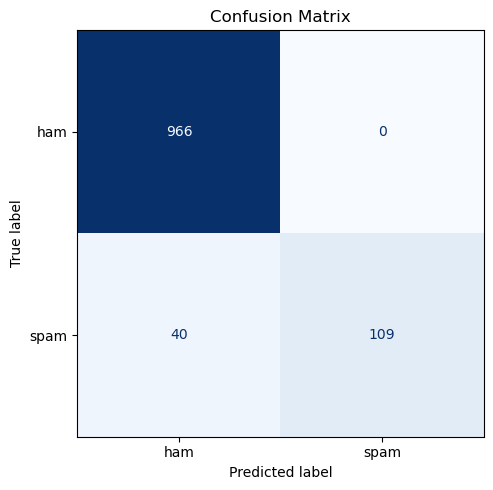

True Negatives  (ham correctly classified):  966
False Positives (ham classified as spam):    0
False Negatives (spam classified as ham):    40
True Positives  (spam correctly classified): 109


In [12]:
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (ham correctly classified):  {tn}")
print(f"False Positives (ham classified as spam):    {fp}")
print(f"False Negatives (spam classified as ham):    {fn}")
print(f"True Positives  (spam correctly classified): {tp}")

## 4. Analysis

### 4.1 Inspect Misclassifications

In [13]:
test_df = X_test.reset_index(drop=True).to_frame()
test_df['true_label']      = y_test.reset_index(drop=True)
test_df['predicted_label'] = y_pred
test_df['original_message'] = sms_data.loc[X_test.index, 'message'].reset_index(drop=True)

false_positives = test_df[(test_df['true_label'] == 'ham') & (test_df['predicted_label'] == 'spam')]
false_negatives = test_df[(test_df['true_label'] == 'spam') & (test_df['predicted_label'] == 'ham')]

print(f"False Positives (ham → spam): {len(false_positives)}")
print(f"False Negatives (spam → ham): {len(false_negatives)}")

False Positives (ham → spam): 0
False Negatives (spam → ham): 40


In [14]:
print("=== False Positives (legitimate messages incorrectly flagged as spam) ===")
for _, row in false_positives.head(5).iterrows():
    print(f"  Message: {row['original_message']}")
    print()

=== False Positives (legitimate messages incorrectly flagged as spam) ===


In [15]:
print("=== False Negatives (spam messages that slipped through) ===")
for _, row in false_negatives.head(5).iterrows():
    print(f"  Message: {row['original_message']}")
    print()

=== False Negatives (spam messages that slipped through) ===
  Message: You are now unsubscribed all services. Get tons of sexy babes or hunks straight to your phone! go to http://gotbabes.co.uk. No subscriptions.

  Message: Wanna get laid 2nite? Want real Dogging locations sent direct to ur mobile? Join the UK's largest Dogging Network. Txt PARK to 69696 now! Nyt. ec2a. 3lp £1.50/msg

  Message: FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv

  Message: Guess what! Somebody you know secretly fancies you! Wanna find out who it is? Give us a call on 09065394514 From Landline DATEBox1282EssexCM61XN 150p/min 18

  Message: Dear Voucher Holder 2 claim your 1st class airport lounge passes when using Your holiday voucher call 08704439680. When booking quote 1st class x 2



### 4.2 Characteristics of Misclassified Messages

In [17]:
test_df['message_length'] = test_df['original_message'].str.len()
test_df['word_count']     = test_df['original_message'].str.split().str.len()

# Re-slice after adding the new columns so each subset has message_length/word_count
categories = {
    'Correct Ham' : test_df[(test_df['true_label'] == 'ham')  & (test_df['predicted_label'] == 'ham')],
    'False Pos'   : test_df[(test_df['true_label'] == 'ham')  & (test_df['predicted_label'] == 'spam')],
    'Correct Spam': test_df[(test_df['true_label'] == 'spam') & (test_df['predicted_label'] == 'spam')],
    'False Neg'   : test_df[(test_df['true_label'] == 'spam') & (test_df['predicted_label'] == 'ham')],
}

summary = pd.DataFrame({
    cat: {'Count': len(df), 'Avg Length': df['message_length'].mean(), 'Avg Words': df['word_count'].mean()}
    for cat, df in categories.items()
}).T.round(1)

print(summary)

              Count  Avg Length  Avg Words
Correct Ham   966.0        74.3       15.0
False Pos       0.0         NaN        NaN
Correct Spam  109.0       143.0       24.3
False Neg      40.0       122.3       21.8


### 4.3 Suggested Improvements

**False Positives** (ham flagged as spam) tend to contain promotional-sounding words ("free", "win", "prize") in legitimate contexts. **False Negatives** (spam that slipped through) often use unusual punctuation, numbers substituted for letters (e.g. "fr33"), or short messages that lack strong spam vocabulary after stemming.

Potential improvements:

| Improvement | Why it helps |
|---|---|
| Add character-level n-gram features | Captures obfuscated words like `fr33` or `w!n` |
| Include message metadata (length, digit ratio, uppercase ratio) | Spam often has high caps/digit usage |
| Try lemmatization instead of stemming | Produces real words, may improve TF-IDF quality |
| Tune `alpha` in MultinomialNB | Smoothing affects precision/recall trade-off |
| Use bigram/trigram TF-IDF (`ngram_range=(1,2)`) | Captures phrases like "free prize" or "call now" |
| Try a complement Naive Bayes (`ComplementNB`) | Better suited to imbalanced datasets like this one |

In [18]:
# Bonus: bigram TF-IDF + ComplementNB to demonstrate one improvement
from sklearn.naive_bayes import ComplementNB

vec2 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train2 = vec2.fit_transform(X_train)
X_test2  = vec2.transform(X_test)

model2 = ComplementNB()
model2.fit(X_train2, y_train)
y_pred2 = model2.predict(X_test2)

print("Improved model (bigram TF-IDF + ComplementNB):")
print(classification_report(y_test, y_pred2))

Improved model (bigram TF-IDF + ComplementNB):
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       966
        spam       0.83      0.91      0.87       149

    accuracy                           0.96      1115
   macro avg       0.91      0.94      0.92      1115
weighted avg       0.96      0.96      0.96      1115

